In [17]:
# Cell 1: Auto-reload setup
%load_ext autoreload
%autoreload 2

# Optional: Also reload imported modules
import sys
import importlib
import xskillscore as xs
xs = importlib.reload(xs)  # ensure new functions are picked up

# Simple 

---

### Deterministic 

Correlation-Based:

- Effective Sample Size (effective_sample_size)
- Pearson Correlation (pearson_r)
- Pearson Correlation effective p value (pearson_r_eff_p_value)
- Pearson Correlation p value (pearson_r_p_value)
- Slope of Linear Fit (linslope)
- Spearman Correlation (spearman_r)
- Spearman Correlation effective p value (spearman_r_eff_p_value)
- Spearman Correlation p value (spearman_r_p_value)

Distance-Based:
- Coefficient of Determination (r2)
- Mean Absolute Error (mae)
- Mean Absolute Percentage Error (mape)
- Mean Error (me)
- Mean Squared Error (mse)
- Median Absolute Error (median_absolute_error)
- Root Mean Squared Error (rmse)
- Symmetric Mean Absolute Percentage Error (smape)


### Probabilistic

- Brier Score (brier_score)
- Brier scores of an ensemble for exceeding given thresholds (threshold_brier_score)
- Continuous Ranked Probability Score with a gaussian distribution (crps_gaussian)
- Continuous Ranked Probability Score with numerical integration of the normal distribution (crps_quadrature)
- Continuous Ranked Probability Score with the ensemble distribution (crps_ensemble)
- Discrimination (discrimination)
- Rank Histogram (rank_histogram)
- Ranked Probability Score (rps)
- Receiver Operating Characteristic (roc)
- Reliability (reliability)


### What we need:

- Anomaly Correlation Coefficient
- RPSS

In [18]:
import numpy as np
import xarray as xr
import xskillscore as xs
import matplotlib.pyplot as plt
np.random.seed(seed=42)

# Add ACC

---

In [ ]:
# import numpy as np
# import xarray as xr
# from xskillscore.core.deterministic import anomaly_correlation_coefficient


# # ======================================================================
# # Manual ACC for a SINGLE gridpoint time series
# # ======================================================================
# def manual_acc_point(obs_ts, fct_ts, clim_ts=None):
#     """
#     Compute manual ACC for a single time series at one grid point.
    
#     Parameters
#     ----------
#     obs_ts : xr.DataArray (time,)
#     fct_ts : xr.DataArray (time,)
#     clim_ts : xr.DataArray (time,) or None
    
#     Returns
#     -------
#     float
#         Manual ACC value.
#     """
#     obs = obs_ts.values
#     fct = fct_ts.values
    
#     if clim_ts is not None:
#         clim = clim_ts.values
#         obs_anom = obs - clim
#         fct_anom = fct - clim
#     else:
#         obs_anom = obs - obs.mean()
#         fct_anom = fct - fct.mean()
    
#     num = np.sum(obs_anom * fct_anom)
#     den = np.sqrt(np.sum(obs_anom**2) * np.sum(fct_anom**2))
    
#     acc = num / den

#     print("\n--- Manual ACC Debug ---")
#     print("obs anomaly      :", obs_anom)
#     print("fct anomaly      :", fct_anom)
#     print("num (cov-like)   :", num)
#     print("den (σa σb)      :", den)
#     print("ACC              :", acc)

#     return acc


# # ======================================================================
# # 1. Coordinates (small 3-day slice for clarity)
# # ======================================================================
# times = np.arange("2000-01-01", "2000-01-04", dtype="datetime64[D]")
# lats  = np.linspace(-30,  30, 4)
# lons  = np.linspace(0,   270, 4)

# nT, nLat, nLon = len(times), len(lats), len(lons)


# # ======================================================================
# # 2. Random OBS
# # ======================================================================
# observations = xr.DataArray(
#     np.random.randn(nT, nLat, nLon),
#     dims=["time", "lat", "lon"],
#     coords={"time": times, "lat": lats, "lon": lons},
#     name="observations",
# )


# # ======================================================================
# # 3. Random 4-member forecast
# # ======================================================================
# fct = xr.DataArray(
#     np.random.randn(4, nT, nLat, nLon),
#     dims=["member", "time", "lat", "lon"],
#     coords={"member": ["m0","m1","m2","m3"], "time": times, "lat": lats, "lon": lons},
#     name="forecast",
# )


# # ======================================================================
# # 4. Random DOY climatology
# # ======================================================================
# doy_vals   = xr.DataArray(times).dt.dayofyear.values
# unique_doy = np.unique(doy_vals)

# clim = xr.DataArray(
#     np.random.randn(len(unique_doy), nLat, nLon),
#     dims=["dayofyear","lat","lon"],
#     coords={"dayofyear": unique_doy, "lat": lats, "lon": lons},
#     name="clim_DOY",
# )

# print("\n===== RAW CLIMATOLOGY =====")
# print(clim)


# # ======================================================================
# # 5. Compute ACC via library
# # ======================================================================
# acc = anomaly_correlation_coefficient(
#     fct,
#     obs,
#     dim="time",
#     climatology=clim,
# )

# print("\n===== ACC RESULT (member, lat, lon) =====")
# print(acc)


# # ======================================================================
# # 6. Sanity checks
# # ======================================================================
# assert acc.notnull().all(), "NaNs in ACC output"
# assert (acc >= -1 - 1e-6).all()
# assert (acc <= 1 + 1e-6).all()
# print("\n✔ ACC valid [-1,1]")


# # ======================================================================
# # 7. Inspect single point using NEW FUNCTION
# # ======================================================================
# m, i, j = 0, 0, 0   # member0, lat0, lon0

# obs_1pt = obs.isel(lat=i, lon=j)
# fct_1pt = fct.isel(member=m, lat=i, lon=j)

# # Map clim(dayofyear) → full time
# clim_1pt = clim.sel(dayofyear=doy_vals).isel(lat=i, lon=j)

# print("\n===== SINGLE POINT VALUES =====")
# print("Obs:", obs_1pt.values)
# print("Fct:", fct_1pt.values)
# print("Clim:", clim_1pt.values)

# manual = manual_acc_point(obs_1pt, fct_1pt, clim_1pt)
# library = float(acc.isel(member=m, lat=i, lon=j).values)

# print("\nManual ACC @ this point:", manual)
# print("Library ACC @ same point:", library)



===== RAW CLIMATOLOGY =====
<xarray.DataArray 'clim_DOY' (dayofyear: 3, lat: 4, lon: 4)> Size: 384B
array([[[-0.48356148, -0.61216692,  0.49120767, -0.35802938],
        [-0.1393972 ,  0.73965315, -1.90935609,  1.31830232],
        [ 0.07268052, -0.41149314, -0.08923415, -0.03757064],
        [-1.7312013 ,  1.49493823,  0.04132563,  0.44300213]],

       [[ 0.95154977, -1.02116246,  0.4734719 , -0.26764109],
        [ 0.84677078, -2.12722742, -0.0990943 , -0.60282066],
        [ 0.43226295,  0.47004419, -0.70762589, -0.71217386],
        [-0.11066537, -0.89664223,  0.8419837 , -0.3692072 ]],

       [[-2.90698822, -0.37482206, -1.03854382, -1.63127582],
        [-1.23742664,  0.10940847,  1.32864083,  0.31318447],
        [-0.60650339,  0.4559042 , -0.45909031, -0.69460037],
        [-1.15436267, -1.75182881, -0.38992371,  0.15805349]]])
Coordinates:
  * dayofyear  (dayofyear) int64 24B 1 2 3
  * lat        (lat) float64 32B -30.0 -10.0 10.0 30.0
  * lon        (lon) float64 32B 0.0 9

/home/hzorkic/files/rwxskillscore/xskillscore/core/deterministic.py:946: UserWarning: rename 'dayofyear' to 'time' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  mapped = mapped.rename({"dayofyear": time_dim})


In [36]:
# import numpy as np
# import xarray as xr
# from xskillscore.core.deterministic import anomaly_correlation_coefficient


# # ======================================================================
# # Manual ACC for a SINGLE gridpoint time series
# # ======================================================================
# def manual_acc_point_members(obs_ts, fct_ts, clim_ts=None):
#     """
#     Compute manual ACC for each forecast member at a single grid point.

#     Parameters
#     ----------
#     obs_ts : xr.DataArray (time,)
#     fct_ts : xr.DataArray (member, time)
#     clim_ts : xr.DataArray (time,) or None

#     Returns
#     -------
#     np.ndarray shape (member,)
#         ACC for each member.
#     """
#     obs = obs_ts.values              # (T,)
#     fct = fct_ts.values              # (M, T)

#     if clim_ts is not None:
#         clim = clim_ts.values        # (T,)
#         obs_anom = obs - clim        # (T,)
#         fct_anom = fct - clim[None,:]  # broadcast → (M, T)
#     else:
#         obs_anom = obs - obs.mean()
#         fct_anom = fct - fct.mean(axis=1, keepdims=True)

#     # numerator: dot(obs_anom, fct_anom_m)
#     num = np.sum(fct_anom * obs_anom[None,:], axis=1)

#     # denominator: ||obs|| * ||fct_m||
#     den = np.sqrt(
#         np.sum(obs_anom**2) * np.sum(fct_anom**2, axis=1)
#     )

#     acc = num / den

#     print("\n--- Manual ACC (Members) Debug ---")
#     print("obs anomaly:", obs_anom)
#     print("fct anomaly:", fct_anom)
#     print("num:", num)
#     print("den:", den)
#     print("ACC:", acc)

#     return acc




===== RAW CLIMATOLOGY =====
<xarray.DataArray 'clim_DOY' (dayofyear: 3, lat: 4, lon: 4)> Size: 384B
array([[[ 6.65416824e-01,  1.94121744e+00, -8.78323077e-01,
         -3.78007899e-01],
        [ 2.31445923e-01,  6.46489538e-01, -2.15667638e-01,
         -8.72961090e-01],
        [ 8.81407529e-01,  7.21135363e-01, -9.16274101e-01,
          1.35544280e+00],
        [ 1.17019871e+00,  1.34296497e-01,  7.95978624e-02,
          5.54057771e-01]],

       [[-8.61703070e-01,  3.00314792e-02, -2.15238354e+00,
          8.76455646e-01],
        [-1.56149322e+00,  1.50341983e+00, -3.30120094e-01,
         -2.11666982e-01],
        [-6.27733906e-01, -2.88038874e-01,  1.41853135e+00,
         -2.48780866e+00],
        [ 1.27696539e+00,  3.38023481e-01, -1.20702165e+00,
         -1.07531239e+00]],

       [[ 1.67639303e+00, -9.45506880e-01, -1.15335051e+00,
          1.13731454e+00],
        [ 3.38552876e-01, -9.37925577e-01,  2.16624975e-01,
         -1.02575268e+00],
        [ 1.10082140e+00,

/home/hzorkic/files/rwxskillscore/xskillscore/core/deterministic.py:946: UserWarning: rename 'dayofyear' to 'time' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  mapped = mapped.rename({"dayofyear": time_dim})


In [ ]:


# # ======================================================================
# # 1. Coordinates (small 3-day slice for clarity)
# # ======================================================================
# times = np.arange("2000-01-01", "2000-01-04", dtype="datetime64[D]")
# lats  = np.linspace(-30,  30, 4)
# lons  = np.linspace(0,   270, 4)

# nT, nLat, nLon = len(times), len(lats), len(lons)


# # ======================================================================
# # 2. Random OBS
# # ======================================================================
# obs = xr.DataArray(
#     np.ones((nT, nLat, nLon)),
#     dims=["time","lat","lon"], coords={"time":times,"lat":lats,"lon":lons}
# )

# # ======================================================================
# # 3. Random 4-member forecast
# # ======================================================================
# fct = xr.DataArray(
#      np.ones((4, nT, nLat, nLon)),
#     dims=["member", "time", "lat", "lon"],
#     coords={"member": ["m0","m1","m2","m3"], "time": times, "lat": lats, "lon": lons},
#     name="forecast",
# )


# # ======================================================================
# # 4. Random DOY climatology
# # ======================================================================
# doy_vals   = xr.DataArray(times).dt.dayofyear.values
# unique_doy = np.unique(doy_vals)

# clim = xr.DataArray(
#     np.random.randn(len(unique_doy), nLat, nLon),
#     dims=["dayofyear","lat","lon"],
#     coords={"dayofyear": unique_doy, "lat": lats, "lon": lons},
#     name="clim_DOY",
# )

# print("\n===== RAW CLIMATOLOGY =====")
# print(clim)


# # ======================================================================
# # 5. Compute ACC via library
# # ======================================================================
# acc = anomaly_correlation_coefficient(
#     fct,
#     obs,
#     dim="time",
#     climatology=clim,
# )

# print("\n===== ACC RESULT (member, lat, lon) =====")
# print(acc)


# # ======================================================================
# # 6. Sanity checks
# # ======================================================================
# assert acc.notnull().all(), "NaNs in ACC output"
# assert (acc >= -1 - 1e-6).all()
# assert (acc <= 1 + 1e-6).all()
# print("\n✔ ACC valid [-1,1]")


# # ======================================================================
# # 7. Inspect single point using NEW FUNCTION
# # ======================================================================
# m, i, j = 0, 0, 0   # member0, lat0, lon0

# obs_1pt = obs.isel(lat=i, lon=j)
# fct_1pt = fct.isel(member=m, lat=i, lon=j)

# # Map clim(dayofyear) → full time
# clim_1pt = clim.sel(dayofyear=doy_vals).isel(lat=i, lon=j)

# print("\n===== SINGLE POINT VALUES =====")
# print("Obs:", obs_1pt.values)
# print("Fct:", fct_1pt.values)
# print("Clim:", clim_1pt.values)

# manual = manual_acc_point(obs_1pt, fct_1pt, clim_1pt)
# library = float(acc.isel(member=m, lat=i, lon=j).values)

# print("\nManual ACC @ this point:", manual)
# print("Library ACC @ same point:", library)


In [ ]:


# # ======================================================================
# # 1. Coordinates (small 3-day slice for clarity)
# # ======================================================================
# times = np.arange("2000-01-01", "2000-01-04", dtype="datetime64[D]")
# lats  = np.linspace(-30,  30, 4)
# lons  = np.linspace(0,   270, 4)

# nT, nLat, nLon = len(times), len(lats), len(lons)


# # ======================================================================
# # 2. Random OBS
# # ======================================================================
# obs = xr.DataArray(
#     np.ones((nT, nLat, nLon)),
#     dims=["time","lat","lon"], coords={"time":times,"lat":lats,"lon":lons}
# )

# # ======================================================================
# # 3. Random 4-member forecast
# # ======================================================================
# fct = xr.DataArray(
#      np.ones((4, nT, nLat, nLon)),
#     dims=["member", "time", "lat", "lon"],
#     coords={"member": ["m0","m1","m2","m3"], "time": times, "lat": lats, "lon": lons},
#     name="forecast",
# )


# # ======================================================================
# # 4. Random DOY climatology
# # ======================================================================
# doy_vals   = xr.DataArray(times).dt.dayofyear.values
# unique_doy = np.unique(doy_vals)

# clim = xr.DataArray(
#     np.ones((len(unique_doy), nLat, nLon)),
#     dims=["dayofyear","lat","lon"],
#     coords={"dayofyear": unique_doy, "lat": lats, "lon": lons},
#     name="clim_DOY",
# )

# print("\n===== RAW CLIMATOLOGY =====")
# print(clim)


# # ======================================================================
# # 5. Compute ACC via library
# # ======================================================================
# acc = anomaly_correlation_coefficient(
#     fct,
#     obs,
#     dim="time",
#     climatology=clim,
# )

# print("\n===== ACC RESULT (member, lat, lon) =====")
# print(acc)


# # ======================================================================
# # 6. Sanity checks
# # ======================================================================
# assert acc.notnull().all(), "NaNs in ACC output"
# assert (acc >= -1 - 1e-6).all()
# assert (acc <= 1 + 1e-6).all()
# print("\n✔ ACC valid [-1,1]")


# # ======================================================================
# # 7. Inspect single point using NEW FUNCTION
# # ======================================================================
# m, i, j = 0, 0, 0   # member0, lat0, lon0

# obs_1pt = obs.isel(lat=i, lon=j)
# fct_1pt = fct.isel(member=m, lat=i, lon=j)

# # Map clim(dayofyear) → full time
# clim_1pt = clim.sel(dayofyear=doy_vals).isel(lat=i, lon=j)

# print("\n===== SINGLE POINT VALUES =====")
# print("Obs:", obs_1pt.values)
# print("Fct:", fct_1pt.values)
# print("Clim:", clim_1pt.values)

# manual = manual_acc_point(obs_1pt, fct_1pt, clim_1pt)
# library = float(acc.isel(member=m, lat=i, lon=j).values)

# print("\nManual ACC @ this point:", manual)
# print("Library ACC @ same point:", library)



===== RAW CLIMATOLOGY =====
<xarray.DataArray 'clim_DOY' (dayofyear: 3, lat: 4, lon: 4)> Size: 384B
array([[[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]]])
Coordinates:
  * dayofyear  (dayofyear) int64 24B 1 2 3
  * lat        (lat) float64 32B -30.0 -10.0 10.0 30.0
  * lon        (lon) float64 32B 0.0 90.0 180.0 270.0

---- ACC function Debug ----
obs anomaly      : [[[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]]
fct anomaly      : [[[[0. 0. 0. 0.]
   [0. 0. 0. 0.]
   [0. 0. 0. 0.]
   [0. 0. 0. 0.]]

  [[0. 0. 0. 0.]
   [0. 0. 0. 0.]
   [0. 0. 0. 0.]
   [0. 0. 0. 0.]]

  [[0. 0. 

/home/hzorkic/files/rwxskillscore/xskillscore/core/deterministic.py:946: UserWarning: rename 'dayofyear' to 'time' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  mapped = mapped.rename({"dayofyear": time_dim})
/tmp/ipykernel_37584/776781513.py:38: RuntimeWarning: invalid value encountered in scalar divide
  acc = num / den


In [100]:
import numpy as np
import xarray as xr
from xskillscore.core.deterministic import anomaly_correlation_coefficient

# ======================================================================
# Manual ACC
# ======================================================================
def manual_acc_point(obs_ts, fct_ts, clim_ts=None):
    obs = obs_ts.values
    fct = fct_ts.values
    
    if clim_ts is not None:
        clim = clim_ts.values
        obs_anom = obs - clim
        fct_anom = fct - clim
    else:
        obs_anom = obs - obs.mean()
        fct_anom = fct - fct.mean()

    num = np.sum(obs_anom * fct_anom)
    den = np.sqrt(np.sum(obs_anom**2) * np.sum(fct_anom**2))

    return num / den


# ======================================================================
# Build tiny test dataset (3 days, 4x4 grid, DOE climatology)
# ======================================================================
times = np.arange("2000-01-01", "2000-01-04", dtype="datetime64[D]")
lats  = np.linspace(-30, 30, 4)
lons  = np.linspace(0,   270, 4)

nT, nLat, nLon = len(times), len(lats), len(lons)

obs = xr.DataArray(
    np.random.randn(nT, nLat, nLon),
    dims=["time","lat","lon"],
    coords={"time":times,"lat":lats,"lon":lons}
)

fct = xr.DataArray(
    np.random.randn(4, nT, nLat, nLon),
    dims=["member","time","lat","lon"],
    coords={"member":["m0","m1","m2","m3"], "time":times,"lat":lats,"lon":lons}
)

doy = xr.DataArray(times).dt.dayofyear.values
unique_doy = np.unique(doy)

clim = xr.DataArray(
    np.random.randn(len(unique_doy), nLat, nLon),
    dims=["dayofyear","lat","lon"],
    coords={"dayofyear":unique_doy,"lat":lats,"lon":lons}
)

acc = anomaly_correlation_coefficient(fct, obs, dim="time", climatology=clim)


# ======================================================================
# Full-grid manual vs library ACC verification
# ======================================================================
print("\n======================== ACC FULL GRID VERIFICATION ========================")

tol = 1e-6
errors = []

for m in range(fct.sizes["member"]):
    for i in range(nLat):
        for j in range(nLon):

            # Extract 1D time series
            obs_ts = obs.isel(lat=i, lon=j)
            fct_ts = fct.isel(member=m, lat=i, lon=j)
            clim_ts = clim.sel(dayofyear=doy).isel(lat=i, lon=j)

            # Compute
            manual = manual_acc_point(obs_ts, fct_ts, clim_ts)
            lib    = float(acc.isel(member=m, lat=i, lon=j).values)

            if not np.isclose(manual, lib, rtol=tol, atol=tol):
                errors.append(((m,i,j), manual, lib))

# ======================================================================
# Report
# ======================================================================
if errors:
    print("\n❌ MISMATCHES FOUND:")
    for (m,i,j), man, lib in errors:
        print(f" member={m}, lat={i}, lon={j} | manual={man:.6f}, lib={lib:.6f}")
else:
    print("\n✔ ALL POINTS MATCH between manual + library ACC")

print("===========================================================================")



======================== ACC FULL GRID VERIFICATION ========================

✔ ALL POINTS MATCH between manual + library ACC


<string>:14: UserWarning: rename 'dayofyear' to 'time' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.


In [101]:
acc

<xarray.DataArray (member: 4, lat: 4, lon: 4)> Size: 512B
array([[[ 0.24268268,  0.93866516,  0.91836817,  0.37102488],
        [-0.34647939,  0.47936465,  0.80560968,  0.33597644],
        [ 0.5994687 ,  0.96688894,  0.76015774, -0.12134705],
        [ 0.2011327 ,  0.8461341 ,  0.36494275,  0.18285268]],

       [[ 0.9959233 ,  0.97473336,  0.15730303,  0.45975351],
        [-0.79942587, -0.19910171,  0.97867731,  0.62361257],
        [ 0.95612506,  0.26223861,  0.33923179,  0.7580915 ],
        [-0.93601855,  0.87731729, -0.77707401,  0.89005887]],

       [[ 0.81084636, -0.90610283,  0.62057954, -0.54392982],
        [ 0.82142513,  0.13136285,  0.88369517,  0.87706697],
        [ 0.94203671,  0.53586337, -0.14883586,  0.58974462],
        [-0.33301681,  0.71430006,  0.33558471,  0.92337644]],

       [[-0.08447944,  0.00871198,  0.85040168, -0.19625877],
        [ 0.89042469,  0.98309955,  0.7112329 ,  0.65822636],
        [ 0.72622328,  0.58583414, -0.00815111, -0.12811471],
        [ 0.60651361,  0.83862779,  0.94277728,  0.96807471]]])
Coordinates:
  * member   (member) <U2 32B 'm0' 'm1' 'm2' 'm3'
  * lat      (lat) float64 32B -30.0 -10.0 10.0 30.0
  * lon      (lon) float64 32B 0.0 90.0 180.0 270.0

# Add Rank Histogram Plotting 

---

BLUE: Low rank-1 frequency (dark colors)

- The observation is rarely the lowest.
- Ensemble forecasts tend to be lower than the truth.
- Indicates overprediction or underconfident lower tail.

YELLOW: High rank-1 frequency (bright colors)

- Observation is very often the lowest.
- Ensemble forecasts tend to be too high relative to reality.
- Indicates warm/wet/high-value bias depending on variable.

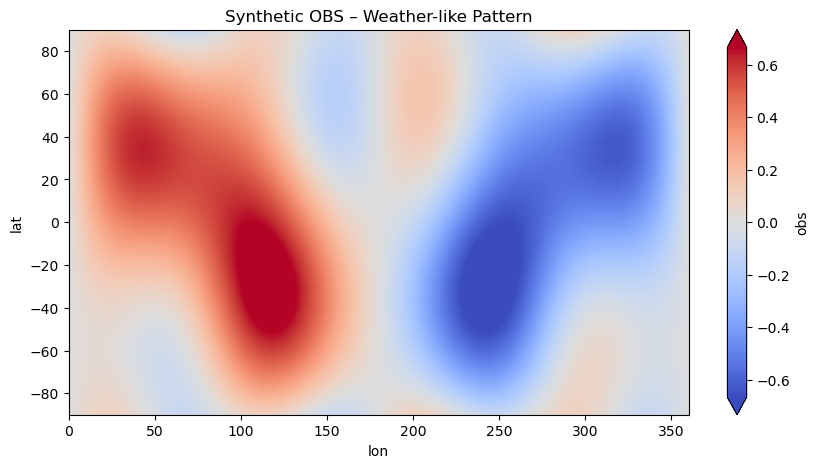


--- Dataset shapes ---
OBS: (20, 720, 1440)
FCT: (20, 4, 720, 1440)
CLIM: (20, 720, 1440)


In [115]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ============================================================
# 1. GLOBAL GRID
# ============================================================
nlat = 720
nlon = 1440
ntime = 20
nmembers = 4

lats = np.linspace(-90 + 0.25/2, 90 - 0.25/2, nlat)
lons = np.linspace(0 + 0.25/2, 360 - 0.25/2, nlon)
times = np.arange("2000-01-01", f"2000-01-{ntime+1}", dtype="datetime64[D]")


# ============================================================
# 2. BASE SYNTHETIC FIELDS (all numpy, Earth-like patterns)
# ============================================================

# Zonal gradient (warm equator, cold poles)
zonal = np.cos(np.deg2rad(lats))[:, None] * np.ones((nlat, nlon))

# Planetary wave (Rossby-like)
k = 4
planetary = (
    np.sin(2*np.pi*k*(lons/360))[None, :]
    * np.cos(np.deg2rad(lats))[:, None]
)

# Spherical harmonic-like pattern Y_{3}^{2}
harmonic = (
    np.cos(3*np.deg2rad(lons))[None, :]
    * np.sin(2*np.deg2rad(lats))[:, None]
)

# Weather-like multiscale field
weather_like = (
    0.6 * np.sin(2*np.pi*(lons/360))[None,:] * np.cos(np.deg2rad(lats))[:,None] +
    0.3 * np.sin(4*np.pi*(lons/360))[None,:] * np.sin(np.deg2rad(2*lats))[:,None] +
    0.1 * np.sin(8*np.pi*(lons/360))[None,:]
)

# === The final base field (numpy)
base_field_np = weather_like


# ============================================================
# 3. Convert base field → DataArray
# ============================================================
base_field = xr.DataArray(
    base_field_np,
    dims=["lat", "lon"],
    coords={"lat": lats, "lon": lons},
    name="base"
)


# ============================================================
# 4. Construct OBS = base_field + seasonal cycle
# ============================================================
season = 0.3 * np.sin(2 * np.pi * np.arange(ntime) / ntime)

obs = xr.concat(
    [base_field + season[t] for t in range(ntime)],
    dim="time"
).assign_coords(time=times)
obs.name = "obs"


# ============================================================
# 5. Ensemble generator (FIXED)
# ============================================================
def make_ensemble(base_da, n_members=4, noise_scale=0.05):
    members = [
        base_da + noise_scale * xr.DataArray(
            np.random.randn(*base_da.shape),
            dims=["lat","lon"],
            coords={"lat": base_da.lat, "lon": base_da.lon},
        )
        for _ in range(n_members)
    ]
    return xr.concat(members, dim="member").assign_coords(member=np.arange(n_members))


# Build full forecast: (member, time, lat, lon)
fct = xr.concat(
    [make_ensemble(base_field) for _ in range(ntime)],
    dim="time"
).assign_coords(time=times)
fct.name = "forecast"


# ============================================================
# 6. Climatology (dayofyear × lat × lon)
# ============================================================
doy = xr.DataArray(times).dt.dayofyear.values
unique_doy = np.unique(doy)

clim = xr.concat(
    [base_field for _ in unique_doy],
    dim="dayofyear"
).assign_coords(dayofyear=unique_doy)
clim.name = "climatology"


# ============================================================
# 7. Quick visual check
# ============================================================
plt.figure(figsize=(10,5))
obs.isel(time=0).plot(cmap="coolwarm", robust=True)
plt.title("Synthetic OBS – Weather-like Pattern")
plt.show()


# ============================================================
# 8. Print dataset shapes
# ============================================================
print("\n--- Dataset shapes ---")
print("OBS:", obs.shape)   # (time=20, lat=720, lon=1440)
print("FCT:", fct.shape)   # (member=4, time=20, lat=720, lon=1440)
print("CLIM:", clim.shape) # (dayofyear=20, lat=720, lon=1440)

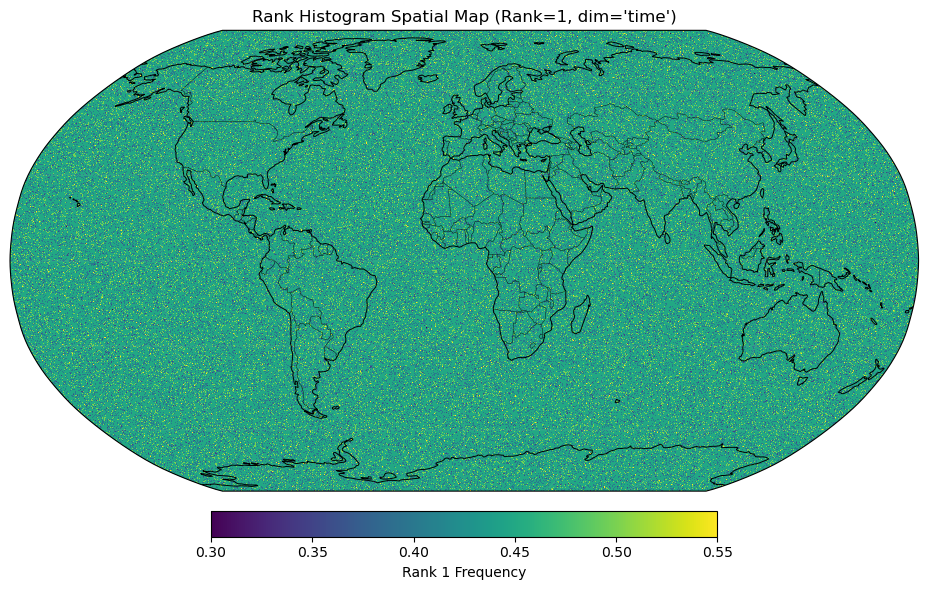

In [120]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from xskillscore.core.probabilistic import rank_histogram
from xskillscore.core.viz import plot_rank_histogram_map_cartopy, plot_rank_histogram


freq_map = plot_rank_histogram_map_cartopy(
    obs,
    fct,
    member_dim="member",
    dim="time",
    rank=1,
    normalize=True,
    projection=ccrs.Robinson(),   # You can choose PlateCarree, Mollweide, etc.
)



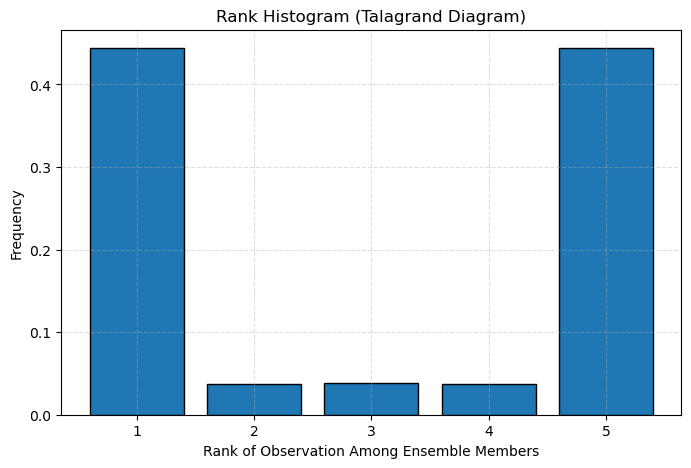

In [121]:
fg = rank_histogram(obs, fct, dim="time", member_dim="member")
plot_rank_histogram(fg)
plt.show()

# RPSS

---

In [15]:
import numpy as np
import xarray as xr

# ============================================================
# 1. Define spatial grid + deterministic obs
# ============================================================
nlat = 10
nlon = 20
ntime = 50
nmember = 20

lat = np.linspace(-40, 40, nlat)
lon = np.linspace(0, 360, nlon)

time = np.arange(ntime)
members = np.arange(nmember)

# Create a synthetic spatial, time-varying observation field
observations = xr.DataArray(
    10
    + 4*np.sin(np.linspace(0, 3*np.pi, ntime))[None, None, :]
    + 0.5*np.random.randn(nlat, nlon, ntime),
    dims=("lat", "lon", "time"),
    coords={"lat": lat, "lon": lon, "time": time},
    name="observations"
)

# ============================================================
# 2. Deterministic ensemble forecasts
# ============================================================
# Slightly noisy versions of obs
fct = xr.DataArray(
    observations.values[None, :, :, :] +
    np.random.normal(scale=1.0, size=(nmember, nlat, nlon, ntime)),
    dims=("member", "lat", "lon", "time"),
    coords={"member": members, "lat": lat, "lon": lon, "time": time},
    name="fct"
)


display(observations)
display(fct)
# ------------------------------------------------------------------
# Import your rpss function (ensure it’s available)
# ------------------------------------------------------------------

from xskillscore.core.probabilistic import rps  # you already have this
from xskillscore.core.utils import _align_climatology
from typing import Optional, Tuple, Union, Literal
from xskillscore.core.types import Dim, XArray
import xarray as xr


<xarray.DataArray 'obs' (lat: 10, lon: 20, time: 50)> Size: 80kB
array([[[10.25174609, 10.20875025, 11.4429141 , ..., 11.64979642,
         11.2875104 , 10.07287825],
        [10.64878363, 10.66541385, 11.12140627, ..., 11.02685239,
         10.48508324,  9.71782051],
        [ 9.62912848, 10.88581209, 11.17164865, ..., 11.79211579,
         10.92739789, 10.43828836],
        ...,
        [10.79908253, 10.83572399, 11.42374132, ..., 12.10097156,
         10.48613032,  9.53148903],
        [10.47115222, 11.74661426, 12.16498362, ..., 11.22764443,
          9.82221307,  9.80391718],
        [ 9.1693219 , 11.03262231, 11.84156773, ..., 12.13335197,
         10.80309965,  9.46110972]],

       [[10.17111209,  9.86116103, 11.5544086 , ..., 11.80824406,
         10.82225586, 10.33308964],
        [10.72192309, 10.71527593, 11.35094523, ..., 12.65439035,
         11.12487827,  9.28212647],
        [10.25846383, 10.9759941 , 11.87117626, ..., 11.91166413,
         11.19116665,  9.91789493],
...
        [ 9.61434293, 10.70693855, 11.65805255, ..., 11.5052655 ,
          9.81815682, 10.63141174],
        [ 9.48830791, 11.0222446 , 11.31019585, ..., 11.15160169,
         10.82678217,  9.90413917],
        [10.38561579, 10.90791177, 10.44893682, ..., 10.98274213,
         10.44731229, 10.17008395]],

       [[ 9.99434902, 10.85494076, 12.39575675, ..., 11.65592265,
         10.16949441, 10.23733275],
        [ 8.2744972 , 10.26572186, 10.24124105, ..., 11.53759373,
         10.01292061, 10.06088578],
        [10.90905447, 10.12617373, 10.4830976 , ..., 10.96585593,
         11.5266101 , 10.15832199],
        ...,
        [ 9.78997976, 10.70639306, 12.60907664, ..., 11.11503896,
         10.43196053, 10.36340116],
        [ 9.27610414, 11.16306328, 10.54088012, ..., 11.73549146,
         10.26701283, 10.99776237],
        [10.3387418 , 10.82422691, 11.19080203, ..., 11.36644446,
         10.50052887, 10.00886584]]], shape=(10, 20, 50))
Coordinates:
  * lat      (lat) float64 80B -40.0 -31.11 -22.22 -13.33 ... 22.22 31.11 40.0
  * lon      (lon) float64 160B 0.0 18.95 37.89 56.84 ... 322.1 341.1 360.0
  * time     (time) int64 400B 0 1 2 3 4 5 6 7 8 ... 41 42 43 44 45 46 47 48 49

<xarray.DataArray 'fct' (member: 20, lat: 10, lon: 20, time: 50)> Size: 2MB
array([[[[ 9.6201069 , 11.14814354, 11.62421404, ..., 12.41301355,
          11.04345395,  9.58414423],
         [10.97522306,  9.95670079,  9.81004902, ...,  9.17995795,
          10.75434096,  9.93624108],
         [ 8.37908509,  9.99047483, 11.28585755, ..., 10.93607595,
          11.34074721,  9.12644726],
         ...,
         [11.13531291, 11.13452631, 11.49777413, ..., 11.38907471,
           8.47352721,  9.08586858],
         [ 9.02963083, 11.52278991, 10.70357266, ..., 11.94705792,
          10.55367942,  9.17852014],
         [10.426979  , 11.25179963, 12.56063208, ..., 12.10747442,
          10.41467641,  8.1018612 ]],

        [[11.35558052, 10.20799137, 12.38682531, ..., 14.07937944,
          10.56765463, 11.3104478 ],
         [10.04101488, 10.06515575, 10.48753698, ..., 11.36486675,
          11.3244172 ,  9.43206802],
         [10.77197597, 10.62547739, 12.95075632, ..., 11.48864669,
          10.67203911, 11.84547473],
...
         [10.76743141, 11.42516508, 11.44979964, ..., 11.06759527,
           9.28973985,  9.81919398],
         [10.14833553, 11.45458952, 11.91676302, ..., 11.42690628,
          10.9217266 , 11.62031837],
         [11.0679023 ,  9.28715282, 12.7910649 , ..., 10.83817462,
          10.61129131, 10.95566842]],

        [[10.5208175 , 10.06022556, 13.76288735, ..., 11.3016254 ,
           9.75258306,  9.8840191 ],
         [ 7.18778164, 10.26724696, 10.16261017, ..., 12.605221  ,
          12.37819375, 10.43372222],
         [11.19886808, 10.53191779,  9.70913449, ...,  9.46075227,
          13.3805714 ,  9.22362893],
         ...,
         [ 9.96518903, 12.0732922 , 15.68165975, ..., 10.83740961,
          11.50563167, 12.10111298],
         [ 9.87495444, 10.38098714, 11.14963115, ..., 13.77827745,
           9.84593712, 11.05398468],
         [11.90781722, 12.07873973, 10.29354675, ..., 11.74781927,
           8.02982206, 11.52082551]]]], shape=(20, 10, 20, 50))
Coordinates:
  * member   (member) int64 160B 0 1 2 3 4 5 6 7 8 ... 12 13 14 15 16 17 18 19
  * lat      (lat) float64 80B -40.0 -31.11 -22.22 -13.33 ... 22.22 31.11 40.0
  * lon      (lon) float64 160B 0.0 18.95 37.89 56.84 ... 322.1 341.1 360.0
  * time     (time) int64 400B 0 1 2 3 4 5 6 7 8 ... 41 42 43 44 45 46 47 48 49

In [25]:
from xskillscore.core.probabilistic import rpss

In [24]:
import numpy as np
import xarray as xr

# ------------------------------------------------------
# 1. Small synthetic grid and time dimension
# ------------------------------------------------------
ntime = 20
nlat = 3
nlon = 4
nmembers = 10

times = np.arange(ntime)
lats = np.linspace(10, 20, nlat)
lons = np.linspace(100, 112, nlon)

# ------------------------------------------------------
# 2. Observations (realistic temperature pattern)
# ------------------------------------------------------
obs_values = 275 + 10*np.random.rand(ntime, nlat, nlon)
obs = xr.DataArray(
    obs_values,
    dims=("time", "lat", "lon"),
    coords={"time": times, "lat": lats, "lon": lons},
    name="t2m",
)

# ------------------------------------------------------
# 3. Random deterministic ensemble forecast
# ------------------------------------------------------
fct_values = 275 + 10*np.random.rand(nmembers, ntime, nlat, nlon)
random_fct = xr.DataArray(
    fct_values,
    dims=("member", "time", "lat", "lon"),
    coords={"member": np.arange(nmembers), "time": times, "lat": lats, "lon": lons},
    name="t2m",
)

# ------------------------------------------------------
# 4. Climatology: smooth seasonal structure
# ------------------------------------------------------
clim_values = obs.mean("time") + np.random.normal(0, 0.5, size=(nlat, nlon))
clim = xr.DataArray(
    clim_values,
    dims=("lat", "lon"),
    coords={"lat": lats, "lon": lons},
    name="t2m_climatology",
).broadcast_like(obs)  # → make it (time, lat, lon)

# ------------------------------------------------------
# 5. Define category thresholds (3-category)
# ------------------------------------------------------
category_edges = np.array([278, 282])

# ------------------------------------------------------
# 6. Compute RPSS
# ------------------------------------------------------
rpss_random = rpss(
    observations=obs,
    forecasts=random_fct,
    category_edges=category_edges,
    climatology=clim,
    dim="time",
)

print("RPSS (random forecast) =", rpss_random.values)


RPSS (random forecast) = [[0.656      0.47214286 0.705      0.64846154]
 [0.60611111 0.5825     0.64038462 0.55863636]
 [0.59409091 0.61923077 0.59384615 0.61321429]]
